In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_parquet(
    "/home/ed/Desktop/TS-Forecasting/data/fhv_tripdata_2026-01.parquet"
)

df.head()

,dispatching_base_num,pickup_datetime,dropOff_datetime,PUlocationID,DOlocationID,SR_Flag,Affiliated_base_number
0,B00112,2026-01-01 00:02:38,2026-01-01 00:33:13,NaN,14.0,NaN,B00112
1,B00112,2026-01-01 00:46:51,2026-01-01 00:54:02,NaN,14.0,NaN,B00112
2,B00112,2026-01-01 00:46:13,2026-01-01 01:13:56,NaN,14.0,NaN,B00112
3,B00112,2026-01-01 00:17:44,2026-01-01 00:24:31,NaN,14.0,NaN,B00112
4,B00112,2026-01-01 00:35:25,2026-01-01 00:40:26,NaN,14.0,NaN,B00112


In [3]:
print("="*80)
print("FHV TAXI DATASET")
print("="*80)

# -------------------------
# BASIC INFO
# -------------------------

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns.tolist())

print("\nData Types")
print(df.dtypes)

print("\nMemory Usage MB")
print(round(df.memory_usage(deep=True).sum()/1024**2,2))


FHV TAXI DATASET

Shape
(1941722, 7)

Columns
['dispatching_base_num', 'pickup_datetime', 'dropOff_datetime', 'PUlocationID', 'DOlocationID', 'SR_Flag', 'Affiliated_base_number']

Data Types
dispatching_base_num                 str
pickup_datetime           datetime64[us]
dropOff_datetime          datetime64[us]
PUlocationID                     float64
DOlocationID                     float64
SR_Flag                          float64
Affiliated_base_number               str
dtype: object

Memory Usage MB
125.47


In [5]:
# -------------------------
# DUPLICATES
# -------------------------

print("\nDuplicates")
print(df.duplicated().sum())



Duplicates
2296


In [6]:
# -------------------------
# DESCRIPTIVE STATS
# -------------------------

print(df.describe())

                  pickup_datetime            dropOff_datetime   PUlocationID  \
count                     1941722                     1941722  295260.000000   
mean   2026-01-16 14:56:04.730911  2026-01-16 15:23:01.457449     127.037022   
min           2026-01-01 00:00:00         2025-01-06 07:37:00       1.000000   
25%           2026-01-08 17:00:00  2026-01-08 17:34:15.250000      63.000000   
50%    2026-01-15 23:06:40.500000         2026-01-15 23:27:36     124.000000   
75%    2026-01-23 16:30:49.500000         2026-01-23 17:01:40     188.000000   
max           2026-01-31 23:59:59         2029-01-13 08:06:00     265.000000   
std                           NaN                         NaN      73.814430   

       DOlocationID  SR_Flag  
count  1.725471e+06      0.0  
mean   1.348820e+02      NaN  
min    1.000000e+00      NaN  
25%    6.900000e+01      NaN  
50%    1.330000e+02      NaN  
75%    2.100000e+02      NaN  
max    2.650000e+02      NaN  
std    7.848772e+01      NaN  


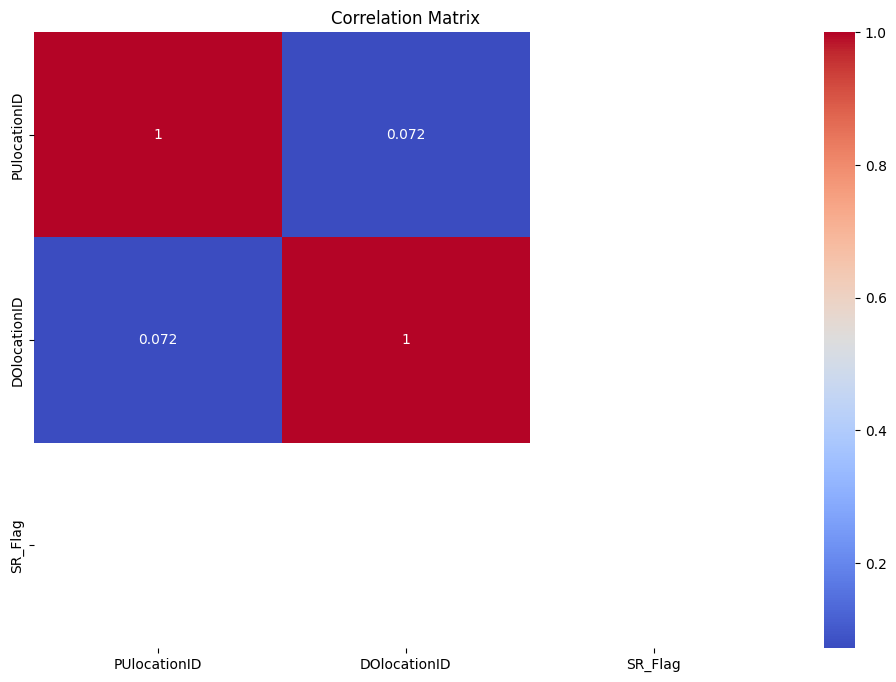

In [7]:
# -------------------------
# CORRELATION
# -------------------------

numeric_cols = df.select_dtypes(include=['number'])
plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()


In [8]:
for col in numeric_cols.columns[:6]:
    print(col)
    print(type(df[col]))
    print(df[col].ndim)
    print("-"*50)

PUlocationID
<class 'pandas.Series'>
1
--------------------------------------------------
DOlocationID
<class 'pandas.Series'>
1
--------------------------------------------------
SR_Flag
<class 'pandas.Series'>
1
--------------------------------------------------


In [9]:
# -------------------------
# TIME COVERAGE
# -------------------------

print(
    "\nPickup Date Range:"
)

print(
    df['pickup_datetime'].min(),
    "to",
    df['pickup_datetime'].max()
)



Pickup Date Range:
2026-01-01 00:00:00 to 2026-01-31 23:59:59



Unique Pickup Zones:
258


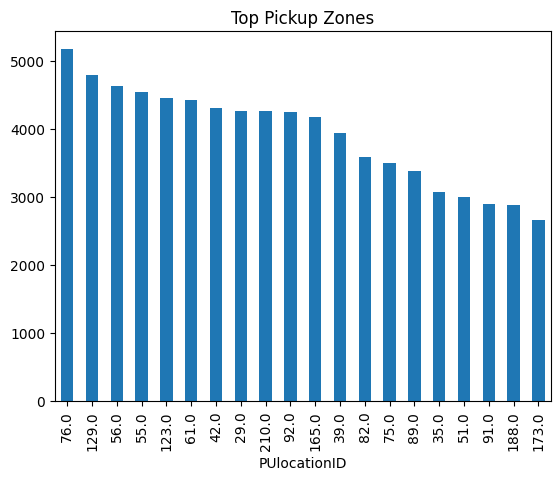

In [10]:
# -------------------------
# ZONE COVERAGE
# -------------------------

print(
    "\nUnique Pickup Zones:"
)

print(
    df['PUlocationID'].nunique()
)

df['PUlocationID'].value_counts()\
.head(20)\
.plot(kind='bar')

plt.title(
    'Top Pickup Zones'
)

plt.show()

In [11]:
# -------------------------
# DEMAND CREATION
# -------------------------

df['hour_bucket'] = (
    df['pickup_datetime']
    .dt.floor('h')
)
df['hour_bucket']



0         2026-01-01 00:00:00
1         2026-01-01 00:00:00
2         2026-01-01 00:00:00
3         2026-01-01 00:00:00
4         2026-01-01 00:00:00
                  ...        
1941717   2026-01-31 23:00:00
1941718   2026-01-31 23:00:00
1941719   2026-01-31 23:00:00
1941720   2026-01-31 23:00:00
1941721   2026-01-31 23:00:00
Name: hour_bucket, Length: 1941722, dtype: datetime64[us]

In [12]:
hourly_demand = (
    df.groupby(
        ['hour_bucket','PUlocationID']
    )
    .size()
    .reset_index(
        name='demand'
    )
)

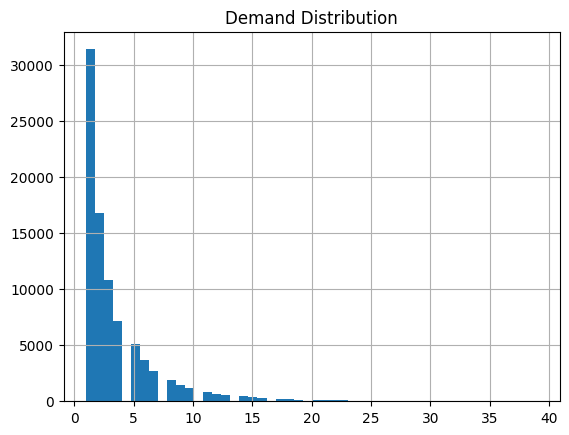

In [13]:
# -------------------------
# DEMAND EDA
# -------------------------

hourly_demand['demand'].hist(
    bins=50
)

plt.title(
    "Demand Distribution"
)

plt.show()

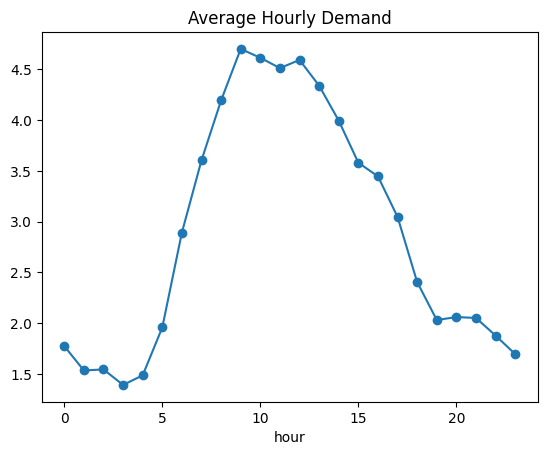

In [14]:

# Hourly Pattern

hourly_demand['hour'] = (
    hourly_demand['hour_bucket']
    .dt.hour
)

hourly_pattern = (
    hourly_demand
    .groupby('hour')['demand']
    .mean()
)

hourly_pattern.plot(
    marker='o'
)

plt.title(
    "Average Hourly Demand"
)

plt.show()


In [15]:
# -------------------------
# FEATURE ENGINEERING
# -------------------------

hourly_demand['day_of_week'] = (
    hourly_demand['hour_bucket']
    .dt.dayofweek
)

hourly_demand['month'] = (
    hourly_demand['hour_bucket']
    .dt.month
)

hourly_demand['is_weekend'] = (
    hourly_demand['day_of_week']>=5
).astype(int)

hourly_demand = hourly_demand.sort_values(
    ['PUlocationID','hour_bucket']
)

hourly_demand['lag_1'] = (
    hourly_demand.groupby(
        'PUlocationID'
    )['demand']
    .shift(1)
)

hourly_demand['lag_24'] = (
    hourly_demand.groupby(
        'PUlocationID'
    )['demand']
    .shift(24)
)


In [16]:
hourly_demand['rolling_mean_24'] = (
    hourly_demand.groupby(
        'PUlocationID'
    )['demand']
    .transform(
        lambda x:
        x.shift(1)
         .rolling(24)
         .mean()
    )
)

print(hourly_demand.sample(10))

              hour_bucket  PUlocationID  demand  hour  day_of_week  month  \
30096 2026-01-11 19:00:00          78.0       3    19            6      1   
27994 2026-01-11 00:00:00         162.0       1     0            6      1   
72676 2026-01-27 11:00:00         197.0       2    11            1      1   
13605 2026-01-06 09:00:00          92.0      12     9            1      1   
49226 2026-01-18 06:00:00          60.0       1     6            6      1   
81378 2026-01-30 08:00:00         114.0       1     8            4      1   
64872 2026-01-23 12:00:00          32.0       2    12            4      1   
65835 2026-01-23 17:00:00           3.0       2    17            4      1   
77296 2026-01-28 22:00:00         129.0       4    22            2      1   
23030 2026-01-09 09:00:00         100.0       2     9            4      1   

       is_weekend  lag_1  lag_24  rolling_mean_24  
30096           1    3.0     6.0         3.041667  
27994           1    1.0     2.0         2.91666